<h1 style="color:#fce444;font-size:45px;font-family:Georgia;text-align:center;"><strong>Appliances Energy⚡ <strong style="color:black;font-size:40px;font-family:Georgia;"> <strong style="color:#fce444;font-size:40px;font-family:Georgia;">"Time Series ⌛ Analysis" <strong style="color:black;font-size:45px;font-family:Georgia;">:- </strong></strong></strong></strong></h1>

# Data Set Information:

The data set is at 10 min for about 4.5 months. The house temperature and humidity conditions were monitored with a ZigBee wireless sensor network. Each wireless node transmitted the temperature and humidity conditions around 3.3 min. Then, the wireless data was averaged for 10 minutes periods. The energy data was logged every 10 minutes with m-bus energy meters. Weather from the nearest airport weather station (Chievres Airport, Belgium) was downloaded from a public data set from Reliable Prognosis (rp5.ru), and merged together with the experimental data sets using the date and time column. Two random variables have been included in the data set for testing the regression models and to filter out non predictive attributes (parameters).


# Attribute Information:

#### date time year-month-day hour:minute:second
#### Appliances, energy use in Wh
#### lights, energy use of light fixtures in the house in Wh
#### T1, Temperature in kitchen area, in Celsius
#### RH_1, Humidity in kitchen area, in %
#### T2, Temperature in living room area, in Celsius
#### RH_2, Humidity in living room area, in %
#### T3, Temperature in laundry room area
#### RH_3, Humidity in laundry room area, in %
#### T4, Temperature in office room, in Celsius
#### RH_4, Humidity in office room, in %
#### T5, Temperature in bathroom, in Celsius
#### RH_5, Humidity in bathroom, in %
#### T6, Temperature outside the building (north side), in Celsius
#### RH_6, Humidity outside the building (north side), in %
#### T7, Temperature in ironing room , in Celsius
#### RH_7, Humidity in ironing room, in %
#### T8, Temperature in teenager room 2, in Celsius
#### RH_8, Humidity in teenager room 2, in %
#### T9, Temperature in parents room, in Celsius
#### RH_9, Humidity in parents room, in %
#### To, Temperature outside (from Chievres weather station), in Celsius
#### Pressure (from Chievres weather station), in mm Hg
#### RH_out, Humidity outside (from Chievres weather station), in %
#### Wind speed (from Chievres weather station), in m/s
#### Visibility (from Chievres weather station), in km
#### Tdewpoint (from Chievres weather station), Â°C
#### rv1, Random variable 1, nondimensional
#### rv2, Random variable 2, nondimensional

Where indicated, hourly data (then interpolated) from the nearest airport weather station (Chievres Airport, Belgium) was downloaded from a public data set from Reliable Prognosis, rp5.ru. Permission was obtained from Reliable Prognosis for the distribution of the 4.5 months of weather data.

# Contents
1. Loading Dataset
2. Exploratory Data Analysis
3. Data Cleaning
4. Data Visualization with time series plots
5. Analysis of Appliances_energy and lights_energy
6. Window Functions
7. Trend, Seasonality and Noise
8. Stationarity
9. AR Models(Time series analysis model)
10. MA Models(Time series analysis model)
11. ARMA Models (Time series analysis model)
12. ARIMA Models(Time series analysis model)
13. VAR Models (Time series analysis model)
14. SARIMA Models (Time series analysis model)
15. Unobserved Components
16. Dynamic Factor Models
17. Data Visualization (heatmap, histogram, bar,scatterplots, boxplots)
18. Feature Selection and Feature Scaling
19. Apply KNN for Lights_energy

In [72]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
plt.rcParams.update(plt.rcParamsDefault)
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")
# settings to display all columns<font></font>
pd.set_option("display.max_columns", None)
# display the dataframe head<font></font>
from pylab import rcParams
from plotly import tools
from plotly.offline import init_notebook_mode
init_notebook_mode(connected=True)
import statsmodels.api as sm
from statsmodels.tsa.arima_model import ARIMA
import math
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score

# Loading DataSet

In [3]:
df = pd.read_csv('energydata_complete.csv')
df.head()


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,RH_5,T6,RH_6,T7,RH_7,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,14/02/2016 0:00,50,10,21.790000,39.900000,20.100000,40.79,21.39,40.59,19.2,41.00,18.200000,52.000,3.530000,91.933333,19.1,37.073333,21.790,44.716667,18.0,41.933333,2.90,732.90,98.000000,2.000000,31.0,2.6,48.320978,48.320978
1,14/02/2016 0:10,50,0,21.790000,39.900000,20.033333,40.73,21.39,40.59,19.2,41.06,18.200000,52.015,3.466667,92.156667,19.1,37.275556,21.790,44.790000,18.0,42.133333,2.87,732.95,98.166667,2.166667,28.5,2.6,33.339359,33.339359
2,14/02/2016 0:20,60,10,21.700000,39.933333,19.890000,40.79,21.39,40.53,19.2,41.09,18.200000,52.090,3.400000,92.165000,19.1,37.461111,21.735,44.873889,18.0,42.360000,2.83,733.00,98.333333,2.333333,26.0,2.6,8.168115,8.168115
3,14/02/2016 0:30,40,0,21.633333,39.860000,19.890000,40.79,21.39,40.59,19.2,41.09,18.188889,52.090,3.400000,92.190000,19.1,37.545000,21.700,45.045000,18.0,42.633333,2.80,733.05,98.500000,2.500000,23.5,2.6,16.197509,16.197509
4,14/02/2016 0:40,60,10,21.600000,39.900000,19.790000,40.79,21.39,40.59,19.1,41.09,18.161111,52.090,3.400000,92.190000,19.1,37.657222,21.740,45.172222,18.0,42.860000,2.77,733.10,98.666667,2.666667,21.0,2.6,12.559574,12.559574


# Exploratory Data Analysis

# Data Cleaning

#### First I want to rename the column names as they were not that easy to read and understand about the data

In [4]:
df.rename(columns = {'Appliances':'Appliances_energy'}, inplace = True)
df.rename(columns={'lights':'lights_energy'} ,inplace=True)
df.rename(columns={'T1':'T_kitchen'} ,inplace=True)
df.rename(columns={'RH_1':'RH_kitchen'} ,inplace=True)
df.rename(columns={'T2':'T_livingroom'} ,inplace=True)
df.rename(columns={'RH_2':'RH_livingroom'} ,inplace=True)
df.rename(columns={'T3':'T_laundryroom'} ,inplace=True)
df.rename(columns={'RH_3':'RH_laundryroom'} ,inplace=True)
df.rename(columns={'T4':'T_officeroom'} ,inplace=True)
df.rename(columns={'RH_4':'RH_officeroom'} ,inplace=True)
df.rename(columns={'T5':'T_bathroom'} ,inplace=True)
df.rename(columns={'RH_5':'RH_bathroom'} ,inplace=True)
df.rename(columns={'T6':'T_OutsideBuliding'} ,inplace=True)
df.rename(columns={'RH_6':'RH_OutsideBuilding'} ,inplace=True)
df.rename(columns={'T7':'T_ironingroom'} ,inplace=True)
df.rename(columns={'RH_7':'RH_ironingroom'} ,inplace=True)
df.rename(columns={'T8':'T_teenagerroom2'} ,inplace=True)
df.rename(columns={'RH_8':'RH_teenagerroom2'} ,inplace=True)
df.rename(columns={'T9':'T_parentsroom'} ,inplace=True)
df.rename(columns={'RH_9':'RH_parentsroom'} ,inplace=True)

#### Throughout the solution keep in mind that T represents Temparature in that room in Celsius and RH represents room humidty in thata room in percentage, Appliances and lights energy in Wh

#### As we can see above that date column is of object type we need to convert it into datetime so that we can do time series forecasting

In [6]:
df['date'] = pd.to_datetime(df['date'])

In [7]:
df.dtypes

date                  datetime64[ns]
Appliances_energy              int64
lights_energy                  int64
T_kitchen                    float64
RH_kitchen                   float64
T_livingroom                 float64
RH_livingroom                float64
T_laundryroom                float64
RH_laundryroom               float64
T_officeroom                 float64
RH_officeroom                float64
T_bathroom                   float64
RH_bathroom                  float64
T_OutsideBuliding            float64
RH_OutsideBuilding           float64
T_ironingroom                float64
RH_ironingroom               float64
T_teenagerroom2              float64
RH_teenagerroom2             float64
T_parentsroom                float64
RH_parentsroom               float64
T_out                        float64
Press_mm_hg                  float64
RH_out                       float64
Windspeed                    float64
Visibility                   float64
Tdewpoint                    float64
r

# Data Visualization

# Analysis of Appliances_energy and lights_energy

#### Now it has been changed to date time lets analyze some time series forecasting

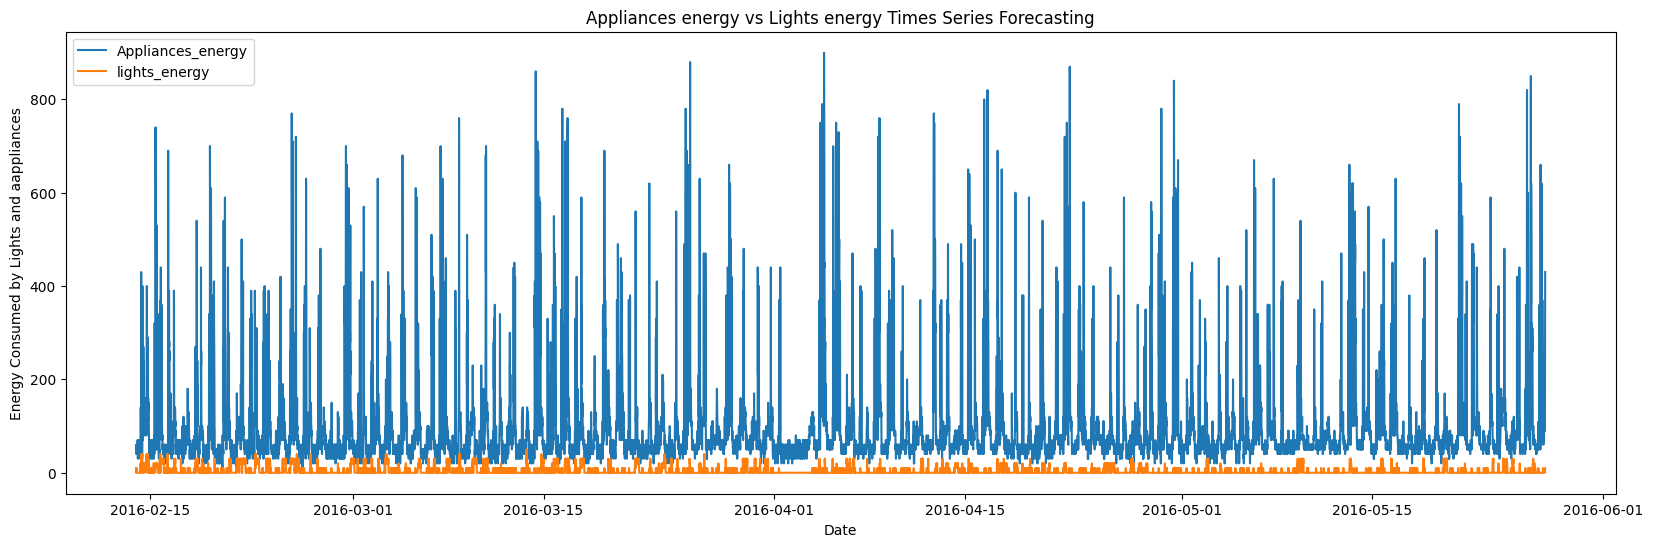

In [8]:
plt.figure(figsize=(20,6))
sns.lineplot(y=df['Appliances_energy'],x = df['date'],linewidth = 1.5 , label = 'Appliances_energy')
sns.lineplot(y=df['lights_energy'],x = df['date'],linewidth = 1.5 , label = 'lights_energy')
plt.xlabel ('Date')
plt.ylabel ('Energy Consumed by Lights and aappliances')
plt.title('Appliances energy vs Lights energy Times Series Forecasting')
plt.show()

>#### Obsevation:
1. Appliances using more energy than Light at maximum times
2. The highest usage of energy for appliances was recoreded in 1st month of 2016
3. Appliances using more energy some days and very less somedays we need to figureout why by comparing with other features
4. Appliances energy usage was very high on starting and ending days of month but alters in middle. For this we have to do analysis on light and appliances energy once again seperatly.

#### From plot I can see some days appliances energy is less than lights energy lets see if my observation is correct or not

In [9]:
df[df['Appliances_energy'] < df['lights_energy']]

,date,Appliances_energy,lights_energy,T_kitchen,RH_kitchen,T_livingroom,RH_livingroom,T_laundryroom,RH_laundryroom,T_officeroom,RH_officeroom,T_bathroom,RH_bathroom,T_OutsideBuliding,RH_OutsideBuilding,T_ironingroom,RH_ironingroom,T_teenagerroom2,RH_teenagerroom2,T_parentsroom,RH_parentsroom,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2


#### My observation is wrong, appliances consumed more energy than lights all the time 

#### Now lets plot Appliances and light energy seperatly 

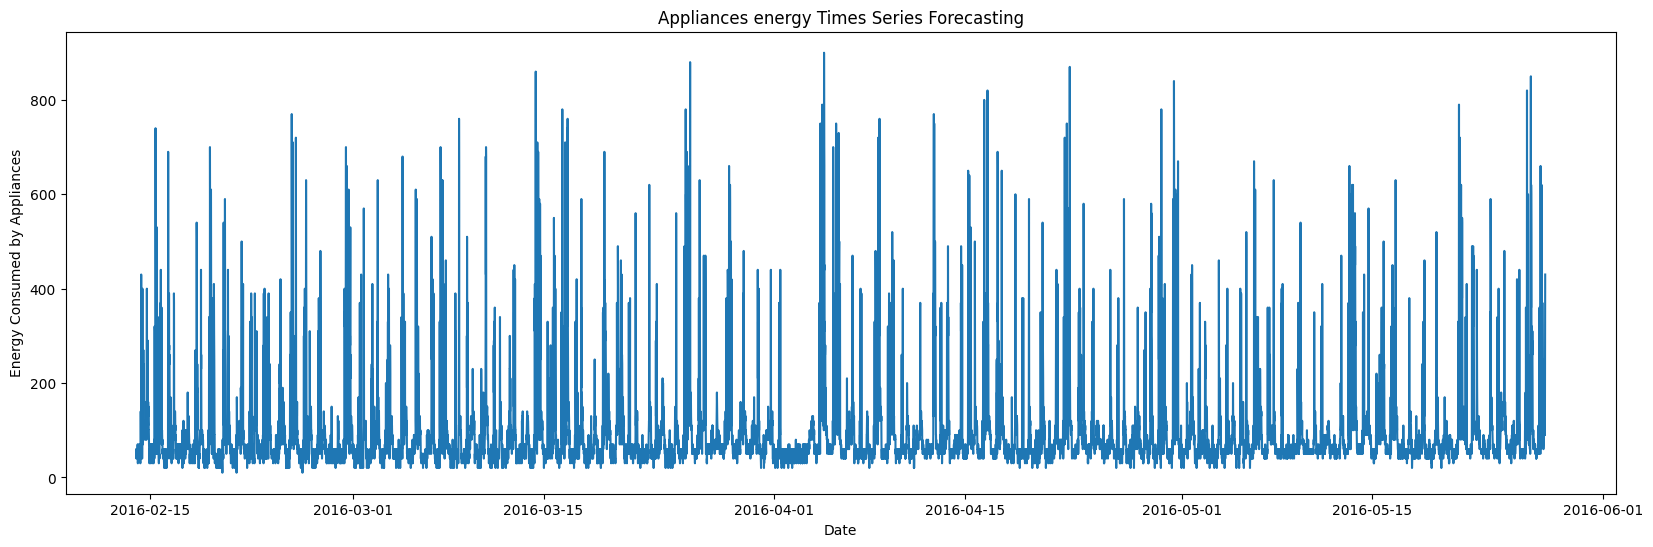

In [10]:
plt.figure(figsize=(20,6))
sns.lineplot(y=df['Appliances_energy'],x = df['date'],linewidth = 1.5)
plt.xlabel ('Date')
plt.ylabel ('Energy Consumed by Appliances')
plt.title('Appliances energy Times Series Forecasting')
plt.show()

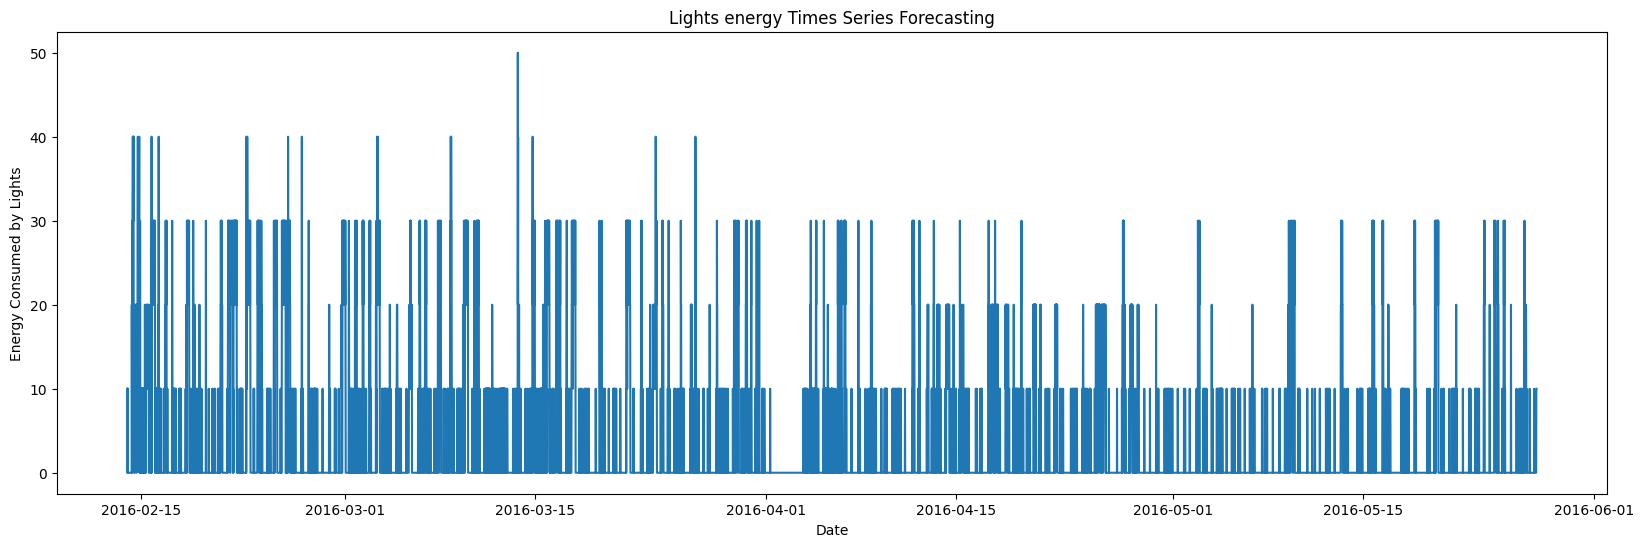

In [11]:
plt.figure(figsize=(20,6))
sns.lineplot(y=df['lights_energy'],x = df['date'],linewidth = 1.5)
plt.xlabel ('Date')
plt.ylabel ('Energy Consumed by Lights')
plt.title('Lights energy Times Series Forecasting')
plt.show()

In [12]:
df['lights_energy'].value_counts()

lights_energy
0     12015
10     1423
20     1125
30      353
40       23
50        2
Name: count, dtype: int64

#### Observation:
1. Most of the times lights energy is zero that means energy used by light fixtures in house is zero
2. Out of 19735 date and time stamps only 2 days have consumed more than 50Wh light energy
3. Out of 19735 date and time stamps only 11 days have consumed more than 40Wh light energy

#### Let us see those days with light energy consumption by light fixtures in the house

In [13]:
df[df['lights_energy'] == 0]['date']

1       2016-02-14 00:10:00
3       2016-02-14 00:30:00
6       2016-02-14 01:00:00
7       2016-02-14 01:10:00
8       2016-02-14 01:20:00
                ...        
14933   2016-05-27 16:50:00
14934   2016-05-27 17:00:00
14935   2016-05-27 17:10:00
14936   2016-05-27 17:20:00
14937   2016-05-27 17:30:00
Name: date, Length: 12015, dtype: datetime64[ns]

In [14]:
df_lights_energy = df.groupby('lights_energy').agg({'Appliances_energy' : 'mean', 'T_kitchen':'mean', 'RH_kitchen':'mean',
                                                   'T_livingroom':'mean', 'RH_livingroom':'mean', 'T_laundryroom':'mean', 
                                                    'RH_laundryroom':'mean','T_officeroom':'mean', 'RH_officeroom':'mean',
                                                    'T_bathroom':'mean', 'RH_bathroom':'mean','T_OutsideBuliding':'mean',
                                                    'RH_OutsideBuilding':'mean', 'T_ironingroom':'mean','RH_ironingroom':'mean',
                                                    'T_teenagerroom2':'mean', 'RH_teenagerroom2':'mean','T_parentsroom':'mean',
                                                    'RH_parentsroom':'mean', 'T_out':'mean', 'Press_mm_hg':'mean', 
                                                    'RH_out':'mean','Windspeed':'mean', 'Visibility':'mean',
                                                   'Tdewpoint':'mean', 'rv1':'mean', 'rv2':'mean'})
df_lights_energy

,Appliances_energy,T_kitchen,RH_kitchen,T_livingroom,RH_livingroom,T_laundryroom,RH_laundryroom,T_officeroom,RH_officeroom,T_bathroom,RH_bathroom,T_OutsideBuliding,RH_OutsideBuilding,T_ironingroom,RH_ironingroom,T_teenagerroom2,RH_teenagerroom2,T_parentsroom,RH_parentsroom,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
lights_energy,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,91.116937,22.087155,39.362405,20.587978,39.920569,22.891153,38.038510,21.453159,37.670149,20.119063,49.134466,9.125955,41.792529,21.051355,34.262439,22.719378,41.622315,20.276242,40.649282,8.403060,755.559277,77.383579,3.648294,37.927380,4.216081,25.013668,25.013668
10,115.600843,21.707216,39.369705,20.158957,39.651461,22.288116,37.730885,21.011826,37.352398,19.620395,49.880851,7.981810,45.654696,20.607118,33.176030,22.509858,40.279802,19.666602,39.702566,7.405964,755.666676,77.181382,3.771013,38.056473,3.282835,25.179106,25.179106
20,123.120000,21.956909,39.895865,20.409089,40.275701,22.390118,38.362900,21.694087,38.292652,19.748504,51.315548,8.052014,50.019492,20.464706,33.843252,22.506827,40.859667,19.648311,39.584905,7.471769,755.516521,78.932762,3.766455,37.976148,3.724961,25.283120,25.283120
30,126.543909,21.722907,39.961591,20.067853,40.476762,21.944347,38.521872,21.410476,38.276179,19.368110,51.094189,6.688862,56.164408,20.049920,33.366053,22.227757,40.511842,19.238060,39.703769,6.338770,756.189377,80.333333,3.750236,37.366383,2.926752,25.219071,25.219071
40,125.217391,20.923659,40.634928,19.113768,41.151884,21.023841,39.121739,20.034420,38.377319,18.469221,55.022101,4.474438,74.539457,19.355350,34.003831,21.461763,40.631727,18.266108,39.673155,4.054783,750.689130,84.775362,3.282609,33.985507,1.551000,21.409901,21.409901
50,85.000000,22.166667,34.045000,20.960000,33.596667,20.775000,35.515000,20.790000,32.830000,18.260000,43.766250,9.383333,23.540000,22.961667,26.046667,24.998333,31.781667,19.390000,37.745000,8.865000,768.383333,57.916667,6.000000,28.000000,1.025000,14.681696,14.681696


### Observation:
1. No relation between light_energy categories and other features in the data

In [15]:
px.bar(data_frame=df_lights_energy.drop(['Press_mm_hg','Appliances_energy'],axis = 1), barmode='group',orientation = 'h',
       width=1000, height=1600,title = "<b>Categories of lights energy</b>",template="plotly_dark")

In [16]:
px.bar(data_frame=df_lights_energy[['Press_mm_hg','Appliances_energy']], barmode='group',
       width=1000, height=500,title = "<b>Categories of lights energy</b>",template="plotly_dark")

#### Let us look at maximum values in each category of lights_energy

In [17]:
lights_energy_max = df.groupby('lights_energy').agg({'Appliances_energy' : 'max', 'T_kitchen':'max', 'RH_kitchen':'max',
                                                   'T_livingroom':'max', 'RH_livingroom':'max', 'T_laundryroom':'max', 
                                                    'RH_laundryroom':'max','T_officeroom':'max', 'RH_officeroom':'max',
                                                    'T_bathroom':'max', 'RH_bathroom':'max','T_OutsideBuliding':'max',
                                                    'RH_OutsideBuilding':'max', 'T_ironingroom':'max','RH_ironingroom':'max',
                                                    'T_teenagerroom2':'max', 'RH_teenagerroom2':'max','T_parentsroom':'max',
                                                    'RH_parentsroom':'max', 'T_out':'max', 'Press_mm_hg':'max', 
                                                    'RH_out':'max','Windspeed':'max', 'Visibility':'max',
                                                   'Tdewpoint':'max', 'rv1':'max', 'rv2':'max'})

In [18]:
lights_energy_max.style.highlight_max(color = 'cyan', axis = 0)

,Appliances_energy,T_kitchen,RH_kitchen,T_livingroom,RH_livingroom,T_laundryroom,RH_laundryroom,T_officeroom,RH_officeroom,T_bathroom,RH_bathroom,T_OutsideBuliding,RH_OutsideBuilding,T_ironingroom,RH_ironingroom,T_teenagerroom2,RH_teenagerroom2,T_parentsroom,RH_parentsroom,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
lights_energy,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,900,26.260000,57.496667,29.856667,56.026667,29.236000,47.693333,26.200000,50.760000,25.795000,93.095714,28.290000,93.500000,26.000000,48.290000,27.230000,55.400000,24.500000,51.536000,26.100000,772.300000,100.000000,13.000000,66.000000,15.500000,49.992758,49.992758
10,880,26.200000,52.633333,27.760000,52.463333,28.628571,47.160000,26.000000,50.400000,25.323333,93.554000,27.552857,93.433333,25.600000,47.590000,27.100000,54.670000,24.434000,51.090000,24.000000,772.283333,100.000000,13.000000,66.000000,15.100000,49.912391,49.912391
20,770,25.600000,49.663333,29.200000,49.033333,28.260000,45.963333,25.963333,49.160000,24.100000,91.346250,27.738571,93.400000,24.890000,45.090000,25.890000,53.260000,24.290000,48.260000,23.600000,771.300000,100.000000,12.000000,65.000000,14.100000,49.910296,49.910296
30,760,25.600000,49.470000,29.260000,48.833333,27.934000,45.230000,26.000000,47.723333,24.066667,90.830000,27.578000,93.300000,24.790000,45.090000,25.890000,52.930000,24.290000,47.626667,23.700000,770.050000,98.833333,12.166667,65.000000,13.600000,49.839707,49.839707
40,310,22.700000,45.800000,20.790000,45.466667,23.066667,42.900000,21.200000,43.930000,20.558333,88.706667,13.417500,92.656667,22.823333,43.590000,25.000000,48.000000,19.890000,45.554000,13.400000,771.200000,98.666667,6.666667,42.500000,7.070000,46.359959,46.359959
50,90,22.200000,34.366667,21.156667,34.196667,20.790000,35.530000,20.790000,33.033333,18.320000,43.942500,9.533333,23.956667,23.033333,26.166667,25.033333,32.466667,19.390000,37.790000,8.930000,768.400000,58.000000,6.000000,28.000000,1.050000,27.899526,27.899526


#### Observation:
1. Most of the maximum values in other featuren columns belong to lights_energy used = 0 category

#### Let us look at minimum values in each category of lights_energy

In [19]:
lights_energy_min = df.groupby('lights_energy').agg({'Appliances_energy' : 'min', 'T_kitchen':'min', 'RH_kitchen':'min',
                                                   'T_livingroom':'min', 'RH_livingroom':'min', 'T_laundryroom':'min', 
                                                    'RH_laundryroom':'min','T_officeroom':'min', 'RH_officeroom':'min',
                                                    'T_bathroom':'min', 'RH_bathroom':'min','T_OutsideBuliding':'min',
                                                    'RH_OutsideBuilding':'min', 'T_ironingroom':'min','RH_ironingroom':'min',
                                                    'T_teenagerroom2':'min', 'RH_teenagerroom2':'min','T_parentsroom':'min',
                                                    'RH_parentsroom':'min', 'T_out':'min', 'Press_mm_hg':'min', 
                                                    'RH_out':'min','Windspeed':'min', 'Visibility':'min',
                                                   'Tdewpoint':'min', 'rv1':'min', 'rv2':'min'})

In [20]:
lights_energy_min.style.highlight_min(color = 'magenta', axis = 0)

,Appliances_energy,T_kitchen,RH_kitchen,T_livingroom,RH_livingroom,T_laundryroom,RH_laundryroom,T_officeroom,RH_officeroom,T_bathroom,RH_bathroom,T_OutsideBuliding,RH_OutsideBuilding,T_ironingroom,RH_ironingroom,T_teenagerroom2,RH_teenagerroom2,T_parentsroom,RH_parentsroom,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
lights_energy,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,10,18.600000,27.233333,16.200000,20.463333,19.133333,28.766667,17.290000,28.424286,16.921429,29.815000,-5.712000,1.000000,17.100000,23.200000,19.000000,29.600000,17.290000,29.166667,-4.400000,732.950000,24.000000,0.000000,1.000000,-5.950000,0.005322,0.005322
10,10,18.600000,27.023333,16.200000,20.833333,19.100000,30.823333,17.500000,28.135714,16.956000,33.323333,-5.690000,1.000000,17.100000,23.730000,19.100000,29.856667,17.290000,29.760000,-4.370000,732.900000,28.666667,0.166667,1.000000,-6.100000,0.033409,0.033409
20,30,19.323333,27.860000,17.033333,25.866667,19.600000,33.626667,17.700000,27.660000,17.000000,35.363333,-5.560000,1.000000,17.290000,23.230000,19.700000,30.360000,17.260000,31.356667,-4.330000,735.333333,31.166667,0.000000,2.166667,-5.930000,0.010019,0.010019
30,40,19.426667,31.926667,17.100000,32.296667,19.600000,33.626667,18.000000,32.156667,17.254000,37.030000,-5.433333,1.000000,17.500000,23.500000,19.790000,30.823333,17.260000,32.637143,-4.320000,735.800000,43.000000,0.500000,20.000000,-6.020000,0.045925,0.045925
40,60,19.963333,37.160000,17.600000,37.293333,19.890000,35.560000,18.700000,34.426667,17.500000,44.266667,-4.060000,27.023333,18.166667,24.390000,20.050000,30.693333,17.500000,35.290000,-3.300000,736.133333,64.000000,1.000000,20.666667,-4.200000,0.175811,0.175811
50,80,22.133333,33.723333,20.763333,32.996667,20.760000,35.500000,20.790000,32.626667,18.200000,43.590000,9.233333,23.123333,22.890000,25.926667,24.963333,31.096667,19.390000,37.700000,8.800000,768.366667,57.833333,6.000000,28.000000,1.000000,1.463865,1.463865


#### Observation:
1. Most of the minimun values in other feature columns belong to lights_energy = 0 and 10 categories

<Figure size 1000x1000 with 0 Axes>

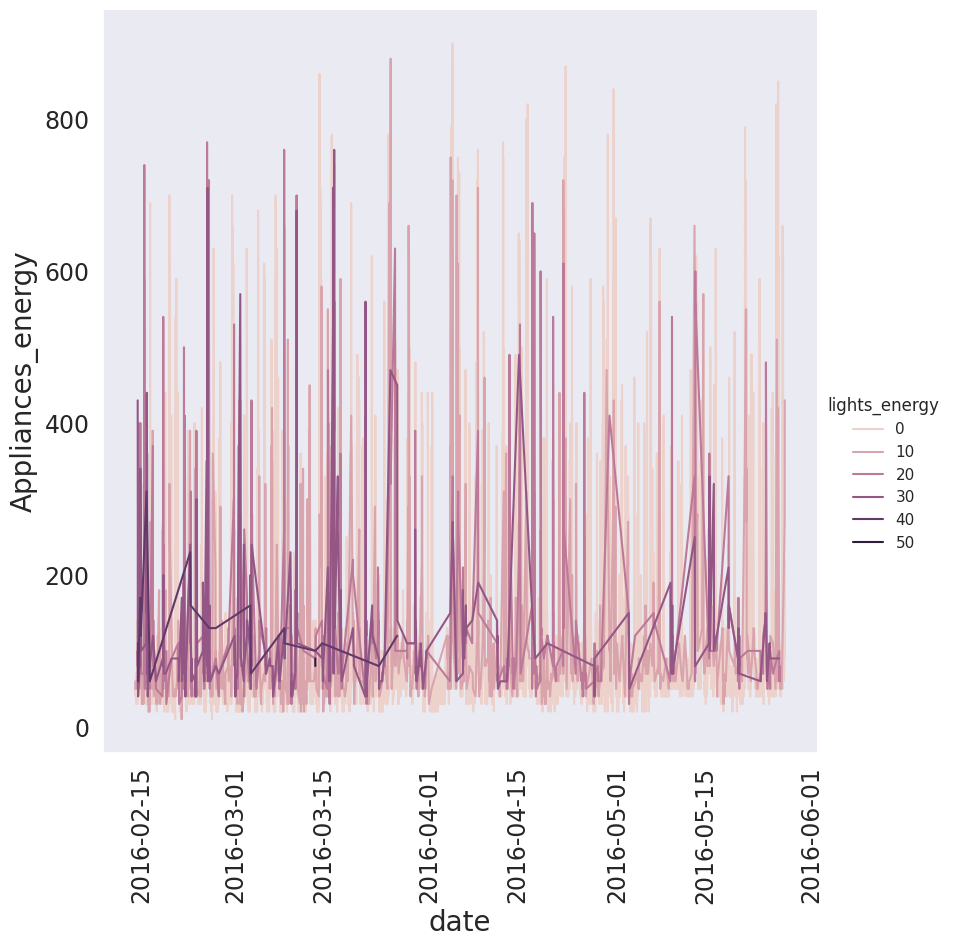

In [21]:
# Combining lineplots using relplot
plt.figure(figsize=(10,10))
sns.set(rc={'xtick.labelsize':17,'ytick.labelsize':17,'axes.labelsize':20  , "axes.grid":False})
sns.relplot(x="date" , y="Appliances_energy" , hue="lights_energy",kind='line', height=8.5, aspect=1 ,data=df)
plt.xticks(rotation=90) # Rotating X tickts by 45 degrees
plt.show()

In [ ]:
# for i in df.columns[3:]:
#     plt.figure(figsize=(20,6))
#     sns.lineplot(y=df[i],x = df['date'],linewidth = 1.5)
#     plt.xlabel ('Date')
#     plt.ylabel (i)
#     plt.title('{} Times Series Forecasting'.format(i))
#     plt.xticks(rotation=90)
#     plt.show()

In [ ]:
# # Combining lineplots using relplot
# for i in df.columns[3:]:
#     plt.figure(figsize=(10,10))
#     sns.relplot(x="date" , y=i , hue="lights_energy",kind='line', height=8.5, aspect=1 ,data=df)
#     plt.xticks(rotation=90) # Rotating X tickts by 45 degrees
#     plt.show()

In [25]:
df.set_index('date',inplace = True)

# Window Functions
Window functions are used to identify sub periods, calculates sub-metrics of sub-periods.

Rolling - Same size and sliding

Expanding - Contains all prior values

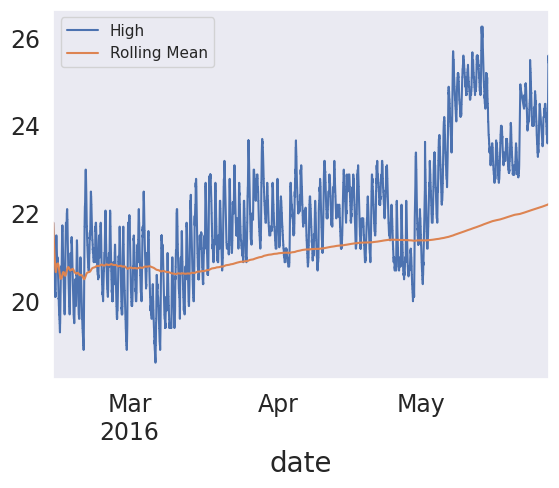

In [27]:
# Rolling window functions or Moving averages are used to smooth out noise in time series data and highlight overall trends
rolling_kitchen = df['T_kitchen'].rolling('90D').mean()
df['T_kitchen'].plot()
rolling_kitchen.plot()
plt.legend(['High','Rolling Mean'])
# Plotting a rolling mean of 90 day window with original High attribute of google stocks
plt.show()

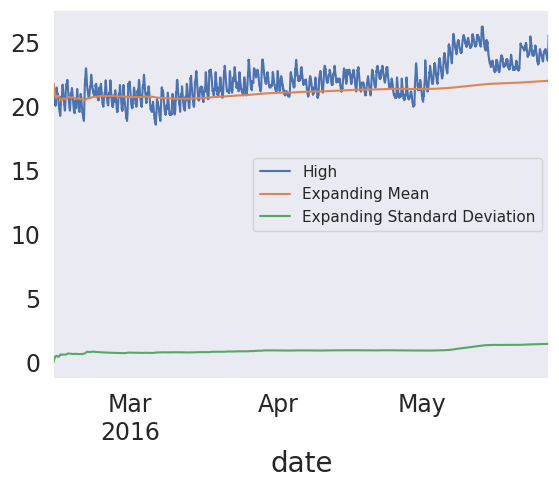

In [30]:
# Expanding window functions. Start of the dataset up to each time step, As more data is included, the mean becomes more stable

T_kitchen_mean = df.T_kitchen.expanding().mean()
T_kitchen_std = df.T_kitchen.expanding().std()
df.T_kitchen.plot()
T_kitchen_mean.plot()
T_kitchen_std.plot()
plt.legend(['High','Expanding Mean','Expanding Standard Deviation'])
plt.show()

# Trend, Seasonality and Noise
## These are the components of a time series
#### Trend - Consistent upwards or downwards slope of a time series
#### Seasonality - Clear periodic pattern of a time series(like sine funtion)
#### Noise - Outliers or missing values

<Axes: xlabel='date'>

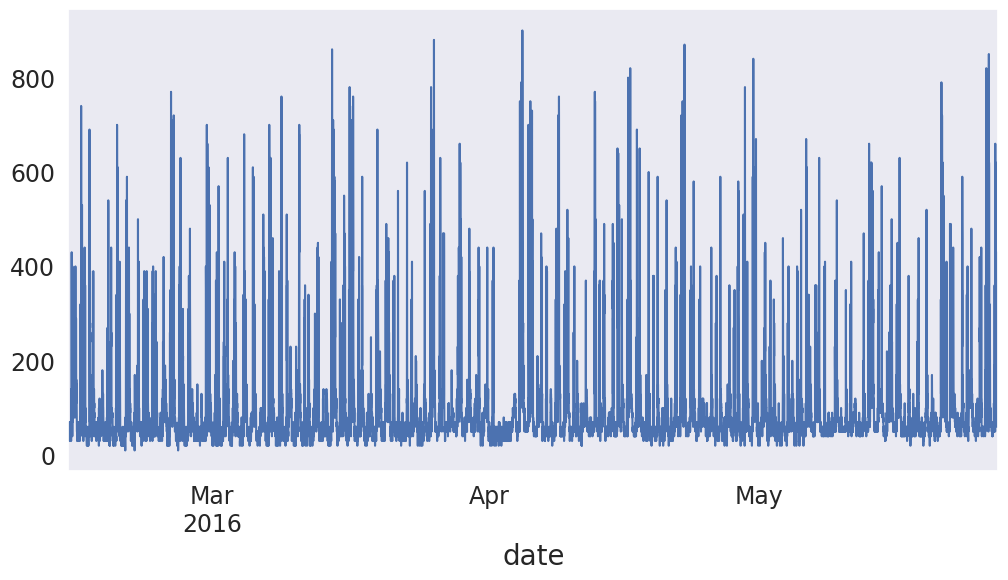

In [49]:
df['Appliances_energy'].plot(figsize=(12,6))

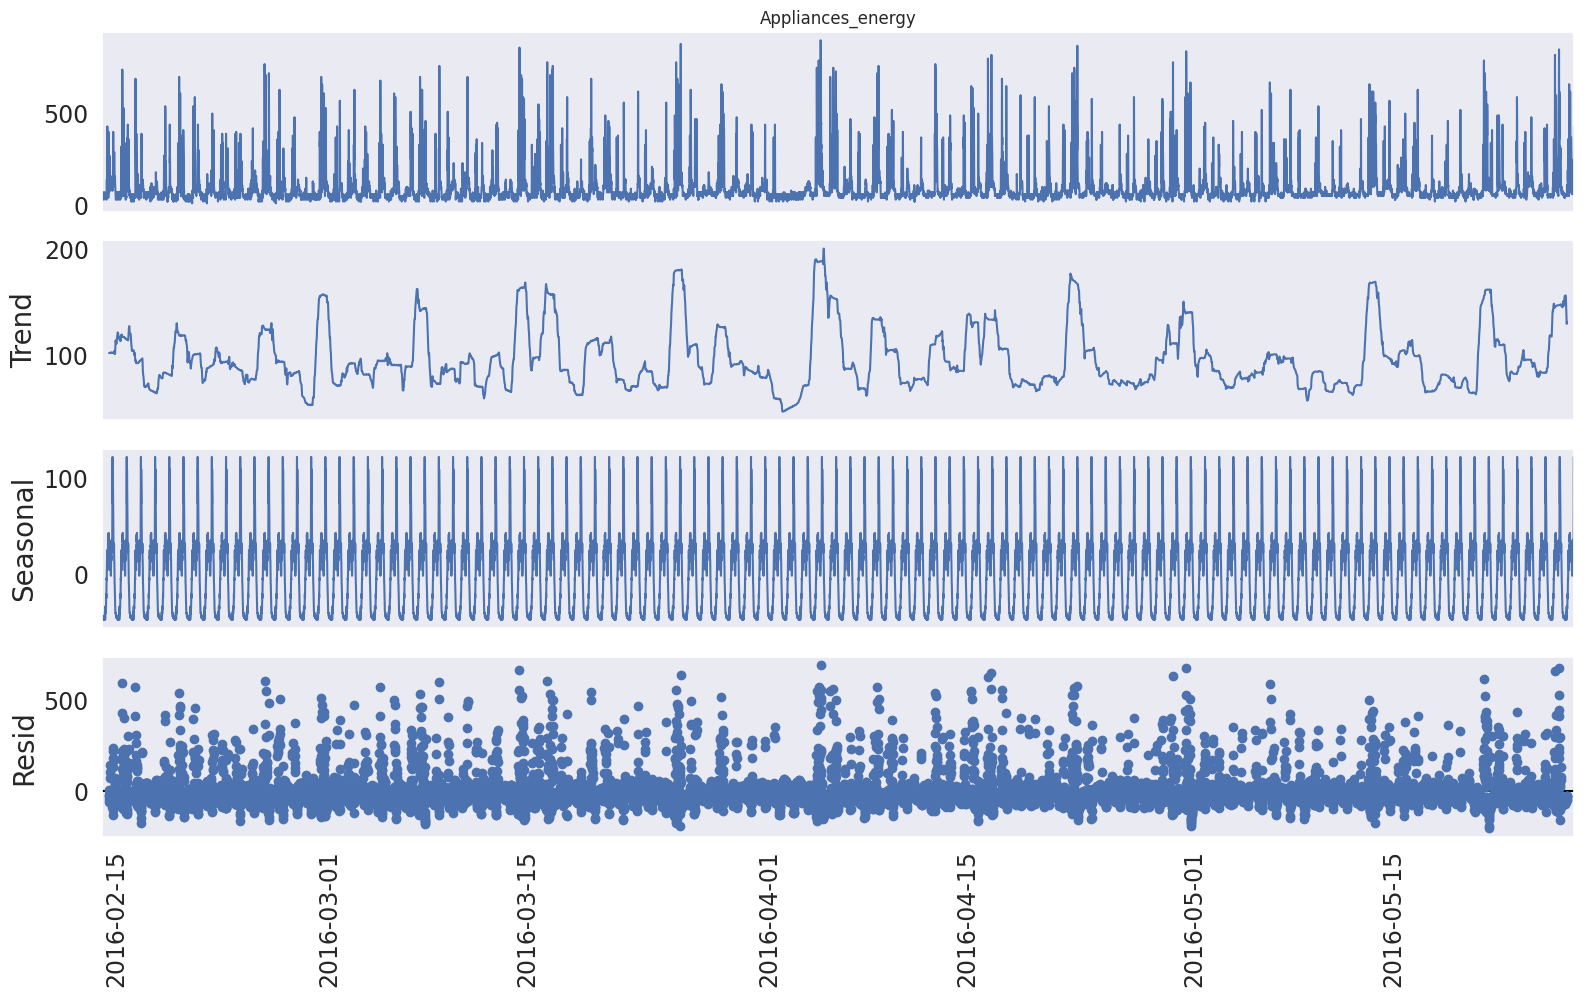

In [57]:
# Now, for decomposition...
rcParams['figure.figsize'] = 16, 9
decomposed_Appliances_volume = sm.tsa.seasonal_decompose(df['Appliances_energy'], period=144) # The period is daily 24*60/10=144
figure = decomposed_Appliances_volume.plot()
plt.xticks(rotation=90) # Rotating X tickts by 45 degrees
plt.show()

#### Observation:
1. There is clearly no trend in the above plot.
2. You can also see the uniform seasonal change.
3. Non-uniform noise that represent outliers and missing values

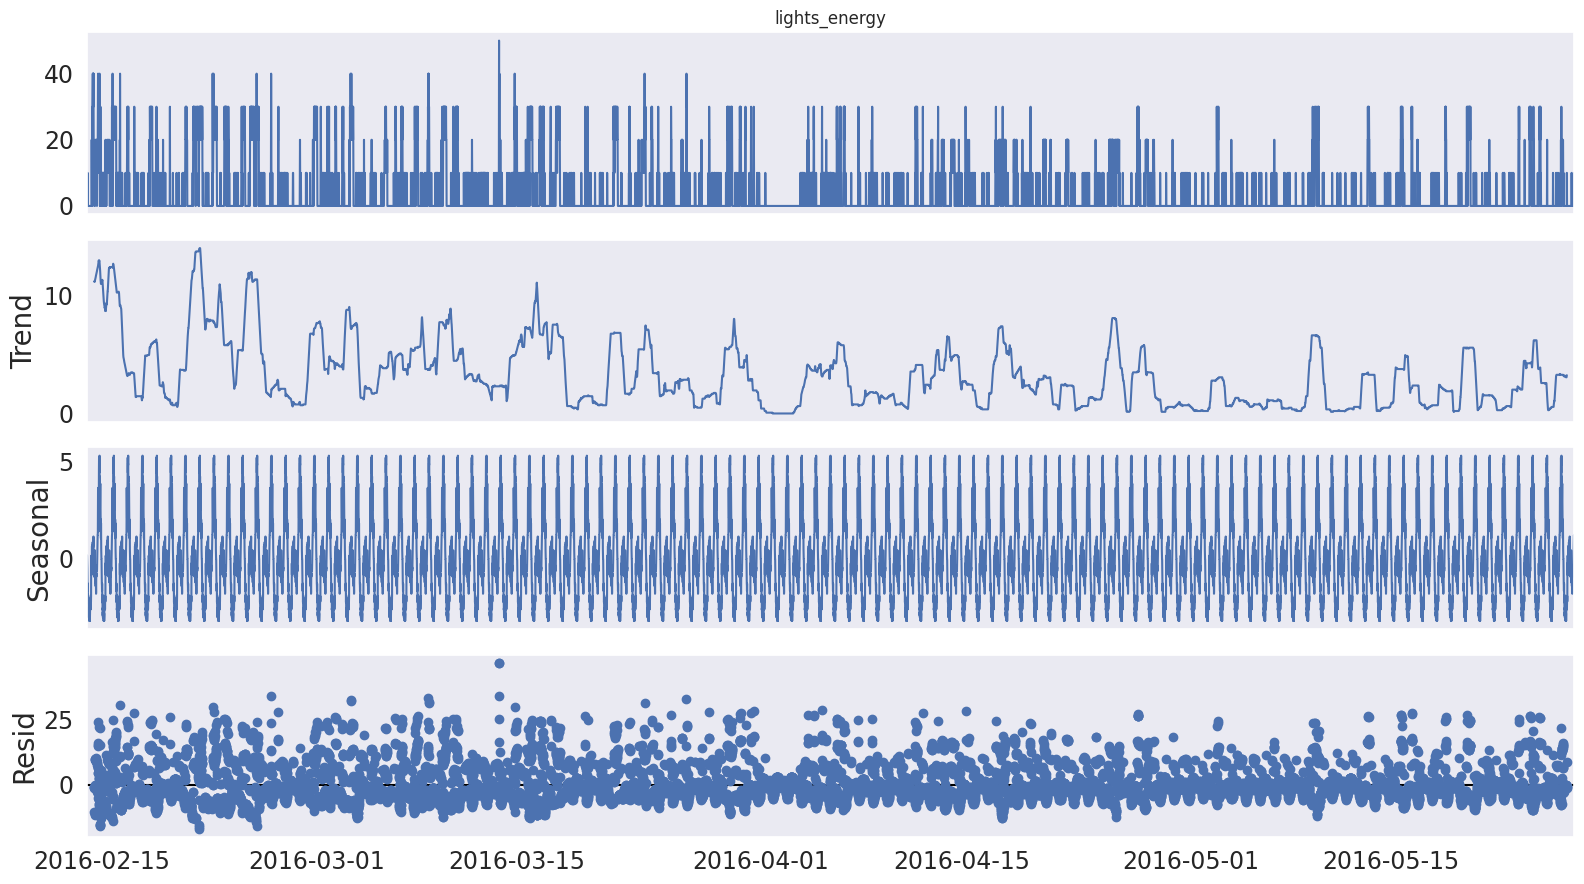

In [53]:
# Now, for decomposition...
rcParams['figure.figsize'] = 16, 9
decomposed_Lights_volume = sm.tsa.seasonal_decompose(df['lights_energy'],period=144) # The frequncy is annual
figure = decomposed_Lights_volume.plot()
#plt.xticks(rotation=90) # Rotating X tickts by 45 degrees
plt.show()

#### Observation:
1. There is some downward trend in the above plot.
2. You can also see the uniform seasonal change.
3. Non-uniform noise that represent outliers and missing values

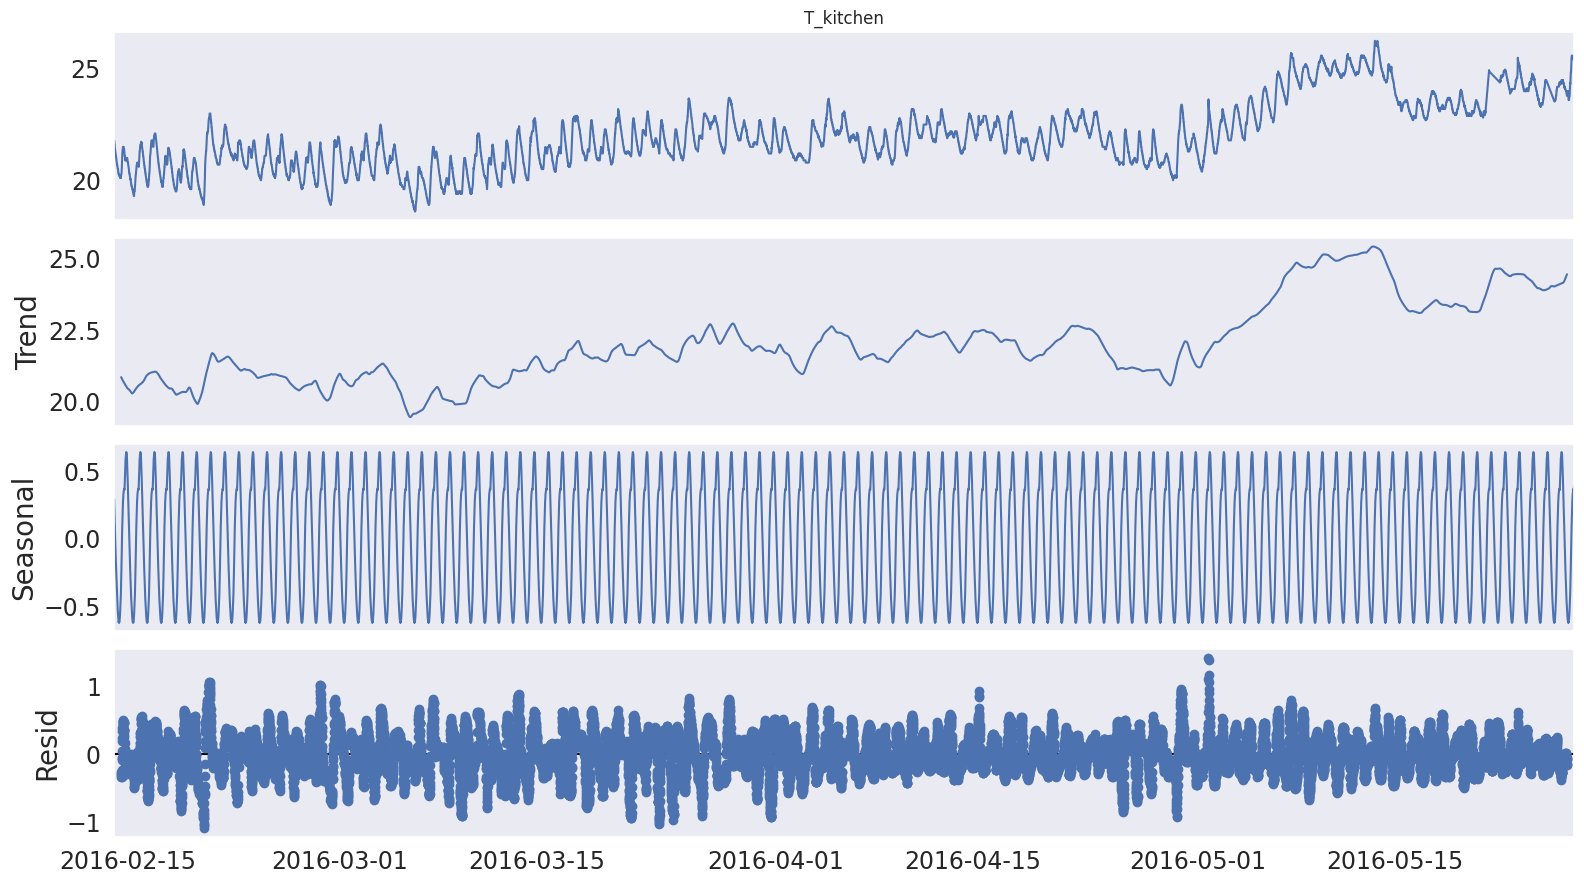

In [54]:
# Now, for decomposition...\
#plt.xticks(rotation=90) # Rotating X tickts by 45 degrees
rcParams['figure.figsize'] = 16, 9
decomposed_T_kitchen_volume = sm.tsa.seasonal_decompose(df['T_kitchen'],period=144) # The frequncy is annual
figure = decomposed_T_kitchen_volume.plot()
plt.show()

#### Observation:
1. There is some upward trend in the above plot.
2. You can also see the uniform seasonal change.
3. Non-uniform noise that represent outliers and missing values

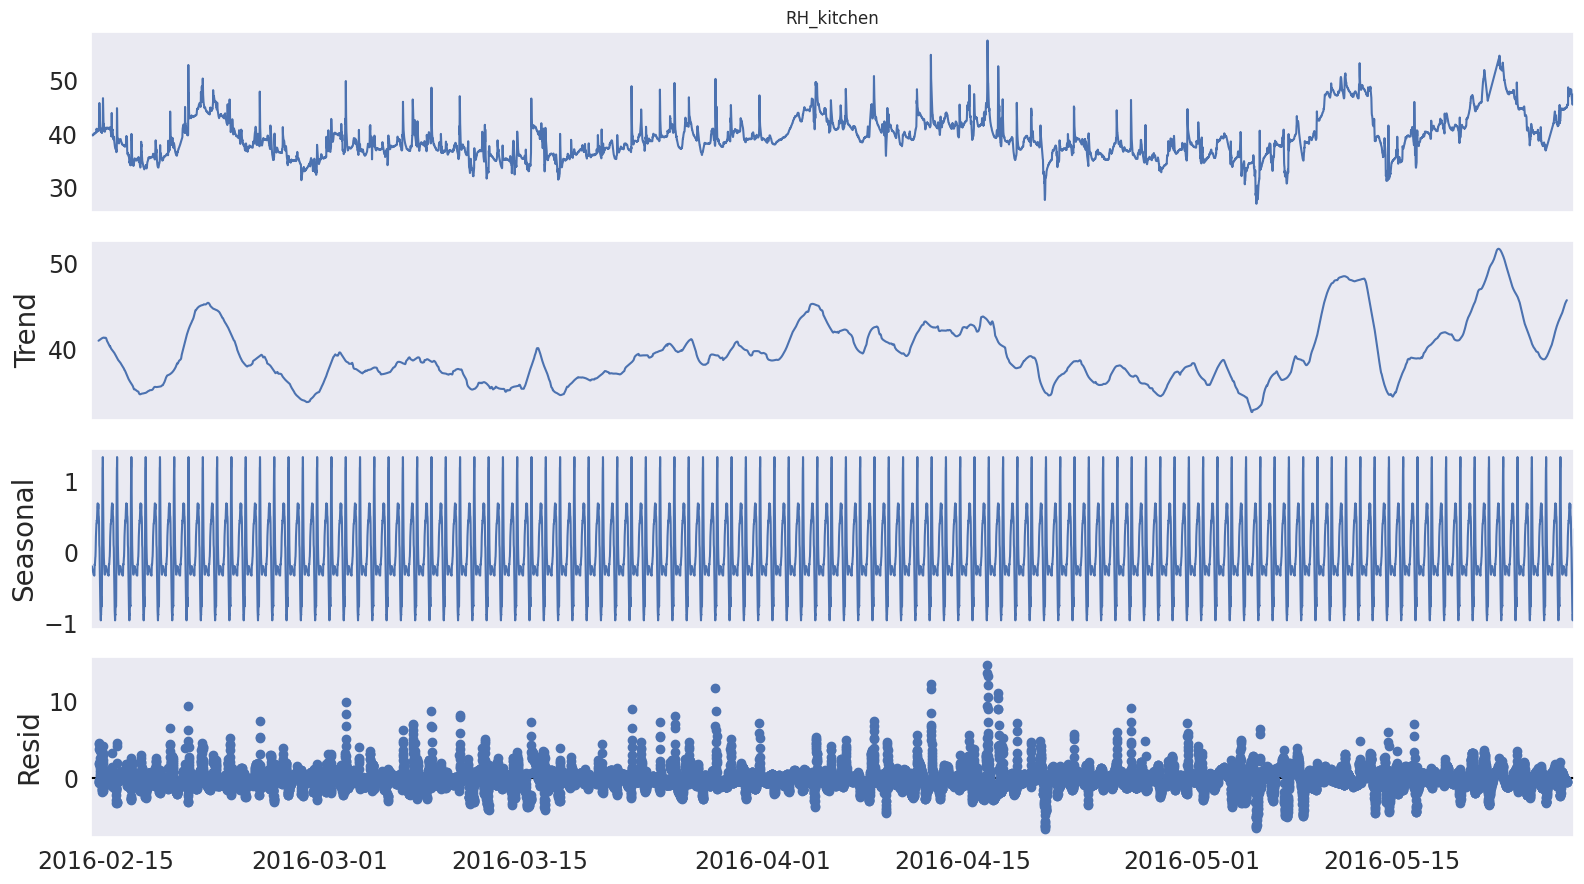

In [55]:
# Now, for decomposition...
#plt.xticks(rotation=90) # Rotating X tickts by 45 degrees
rcParams['figure.figsize'] = 16, 9
decomposed_RH_kitchen_volume = sm.tsa.seasonal_decompose(df['RH_kitchen'],period=144) # The frequncy is annual
figure = decomposed_RH_kitchen_volume.plot()
plt.show()

#### Observation:
1. There is no trend in the above plot.
2. You can also see the uniform seasonal change.
3. Non-uniform noise that represent outliers and missing values

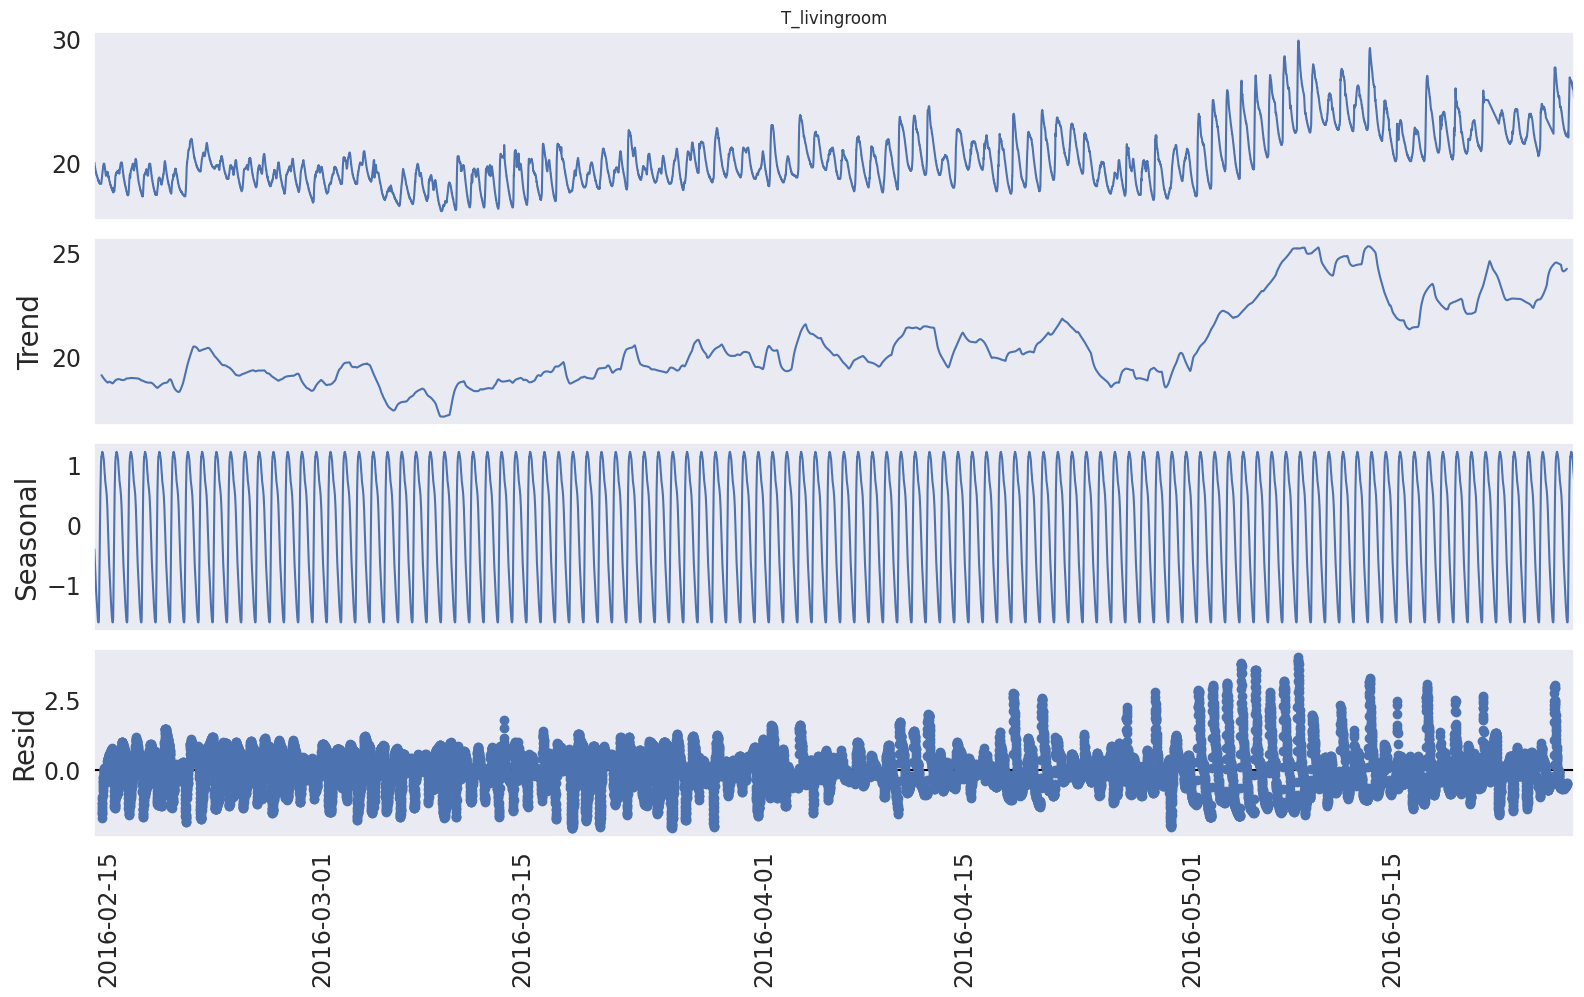

In [56]:
# Now, for decomposition...
rcParams['figure.figsize'] = 16, 9
decomposed_T_livingroom_volume = sm.tsa.seasonal_decompose(df['T_livingroom'],period=144) # The frequncy is annual
figure = decomposed_T_livingroom_volume.plot()
plt.xticks(rotation=90) # Rotating X tickts by 45 degrees
plt.show()

#### Observation:
1. There is some upward trend in the above plot.
2. You can also see the uniform seasonal change.
3. Non-uniform noise that represent outliers and missing values

# Stationarity
A stationary time series is one whose statistical properties such as mean, variance, autocorrelation, etc. are all constant over time.

Strong stationarity: is a stochastic process whose unconditional joint probability distribution does not change when shifted in time. Consequently, parameters such as mean and variance also do not change over time.
Weak stationarity: is a process where mean, variance, autocorrelation are constant throughout the time
Stationarity is important as non-stationary series that depend on time have too many parameters to account for when modelling the time series. diff() method can easily convert a non-stationary series to a stationary series.

We will try to decompose seasonal component of the above decomposed time series.

<Axes: xlabel='date'>

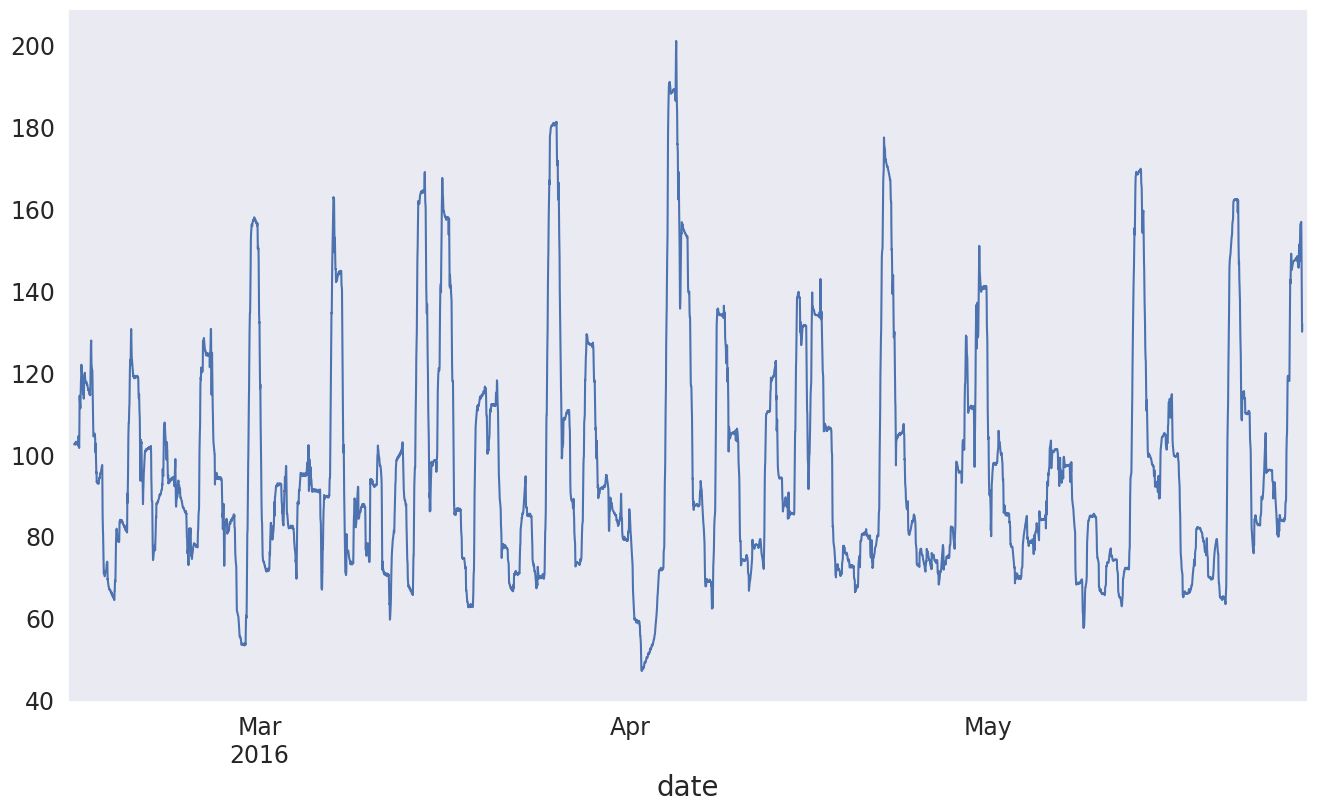

In [58]:
decomposed_Appliances_volume.trend.plot()

<Axes: xlabel='date'>

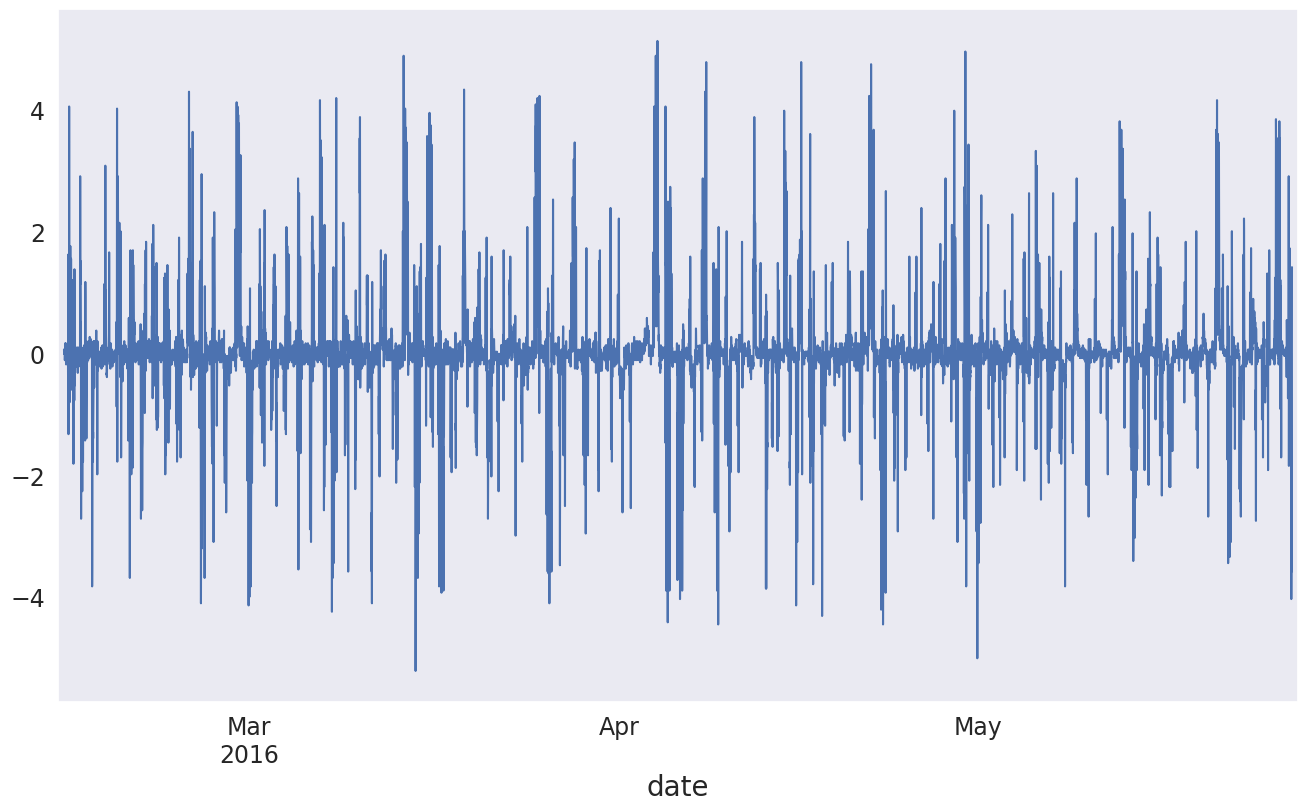

In [59]:
decomposed_Appliances_volume.trend.diff().plot()

fluctuated around 0 => Data is stationary => suitable for ARIMA models

# Prediction using ARIMA model

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                14940
Model:                 ARIMA(2, 1, 0)   Log Likelihood              -87695.038
Date:                Mon, 10 Mar 2025   AIC                         175396.077
Time:                        15:58:06   BIC                         175418.912
Sample:                             0   HQIC                        175403.654
                              - 14940                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5857      0.003   -190.236      0.000      -0.592      -0.580
ar.L2         -0.4047      0.004   -115.043      0.000      -0.412      -0.398
sigma2      7351.2870     29.352    250.456      0.0

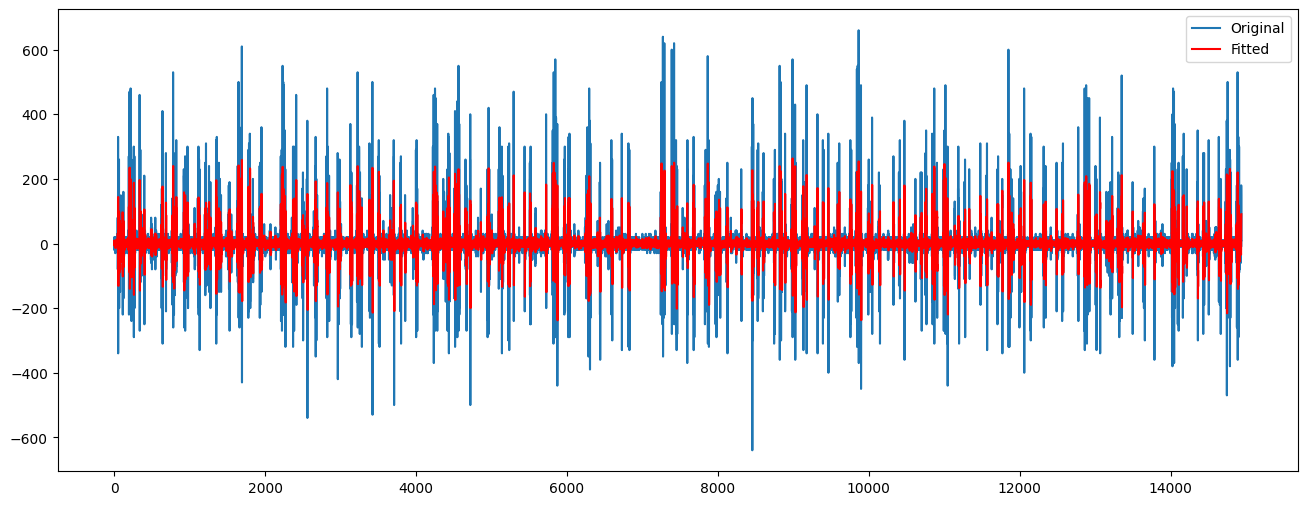

In [83]:
from statsmodels.tsa.arima_model import ARIMA

# 1,1,2 ARIMA Model
model = sm.tsa.arima.ARIMA(df['Appliances_energy'].diff().iloc[1:].values, order=(2,1,0))
model_fit = model.fit()
print(model_fit.summary())
plt.plot(df['Appliances_energy'].diff().iloc[1:].values, label='Original')
plt.plot(model_fit.fittedvalues, color='red', label='Fitted')
plt.legend()
plt.show()

In [84]:
rmse = math.sqrt(mean_squared_error(df['Appliances_energy'].diff().iloc[700:1001].values, model_fit.predict(start=700,end=1000)))
print("The root mean squared error is {}.".format(rmse))

The root mean squared error is 62.398459292493555.


Taking the slight lag into account, this is a fine model.